In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Standard library
import gc
import logging
import warnings
from pathlib import Path

# Third‑party libraries
import dask.dataframe as dd
import polars as pl
import shap
import xgboost as xgb
from dask.distributed import Client, LocalCluster, wait
from make_experiment import Experiment
from newutils.data.datasets import add_lags
from newutils.other.helpers import init_context
from oldutils.datasets import (
    ARTIFACTS_FOLDER,
    STATIC_FEATURES,
    HydroStaticFeaturesFiles,
)
from oldutils.types import TimeRange

init_context()

In [ ]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [4]:
HORIZON_HISTORY = TimeRange.YEAR
HORIZON_FORECAST = TimeRange.WEEK
PARTITION_SIZE = "50MB"
N_WORKERS = 2

COL_GAUGE_ID = "gauge_id"
TARGETS = ["q_mm_day"]

In [5]:
cluster = LocalCluster(
    dashboard_address=":8789",
    asynchronous=False,
    n_workers=N_WORKERS,
    threads_per_worker=1,
    memory_limit="2.5GB",
)
client = Client(cluster)

In [ ]:

params = {
    "tree_method": "hist",
    # 'device': 'cuda',
    "learning_rate": 0.001,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 1,
    # "objective": "reg:squarederror",
    "eval_metric": "mape",
    "num_boost_round": 100,
    "verbose_eval": 10,
    "n_jobs": -1,
}

outpath = Path("artifacts")
outpath.mkdir(parents=True, exist_ok=True)
experiment = Experiment(client, outpath)

In [10]:
experiment.model_paths

[PosixPath('artifacts/model2025-05-12_101030.json')]

In [7]:
experiment.make_experiment(params, num_load=1)

2025-05-12 10:34:23,370 - make_experiment - INFO - Load driver data.
2025-05-12 10:34:23,385 - make_experiment - INFO - Make repartition (100MB).
2025-05-12 10:34:23,385 - make_experiment - INFO - Persist.
2025-05-12 10:34:24,203 - make_experiment - INFO - Persist.
2025-05-12 10:34:24,212 - make_experiment - INFO - Make repartition (50MB).
2025-05-12 10:34:24,213 - make_experiment - INFO - Persist.
2025-05-12 10:34:24,262 - make_experiment - INFO - Generate lags features.
2025-05-12 10:34:25,397 - make_experiment - INFO - Persist.
2025-05-12 10:34:27,560 - make_experiment - INFO - Make repartition (50MB).
2025-05-12 10:34:27,561 - make_experiment - INFO - Persist.
2025-05-12 10:34:28,351 - make_experiment - INFO - Clear dataset from nans.
2025-05-12 10:34:28,354 - make_experiment - INFO - Persist.
2025-05-12 10:34:28,601 - make_experiment - INFO - Add static features.
2025-05-12 10:34:28,768 - make_experiment - INFO - Persist.
2025-05-12 10:34:29,356 - make_experiment - INFO - Make rep

In [ ]:
# client.close()
# cluster.close()
# gc.collect()

In [ ]:


PATH_MERGED_DATASETS = ARTIFACTS_FOLDER / "merged_datasets"
FILENAME_TRAIN_IDS = "train_file_ids.csv"
COL_GAUGE_ID = "gauge_id"

train_df = pl.read_csv(PATH_MERGED_DATASETS / FILENAME_TRAIN_IDS)
file_ids = train_df["file_id"].to_list()[0:1]
paths = [PATH_MERGED_DATASETS / f"{file_id}.parquet" for file_id in file_ids]
df_test = dd.read_parquet(paths)
lags = range(1, HORIZON_HISTORY + 1)

lags_columns = ["prcp", "t_max", "t_min", "t_mean", "lvl_sm"]  # + ["q_mm_day"]
df_test = add_lags(df_test, lags_columns, lags)

targets = []
df_test = add_lags(df_test, targets, range(1, HORIZON_FORECAST + 1), targets)
targets.extend(TARGETS)

df_test = df_test.dropna()
hsff = (
    HydroStaticFeaturesFiles()
    .dataframe.collect()
    .to_pandas()[STATIC_FEATURES + ["gauge_id"]]
)
hsff = dd.from_pandas(hsff)
df_test = df_test.merge(hsff, how="left", on="gauge_id")
df_test = df_test.repartition(partition_size=PARTITION_SIZE)
df_test = client.persist(df_test)
wait(df_test)

/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/dask/dataframe/multi.py:169: UserWarning: Merging dataframes with merge column data type mismatches: 
+--------------------------+------------+-------------+
| Merge columns            | left dtype | right dtype |
+--------------------------+------------+-------------+
| ('gauge_id', 'gauge_id') | int32      | int64       |
+--------------------------+------------+-------------+
Cast dtypes explicitly to avoid unexpected results.
  warnings.warn(


DoneAndNotDoneFutures(done={<Future: finished, type: pandas.core.frame.DataFrame, key: ('repartitionsize-ea31bbee45fd00cdca921aded66e9f08', 0)>, <Future: finished, type: pandas.core.frame.DataFrame, key: ('repartitionsize-ea31bbee45fd00cdca921aded66e9f08', 1)>}, not_done=set())

In [30]:
X_test = client.persist(df_test.drop(columns=set(lags_columns + targets + ["date"])))

In [31]:
# X_test = client.persist(X)

In [ ]:
booster = xgb.Booster()

booster.load_model(experiment.model_paths[-1])

# dtest = xgb.DMatrix(data=X_train)
# preds = booster.predict(dtest)

In [ ]:
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test.sample(frac=0.01))

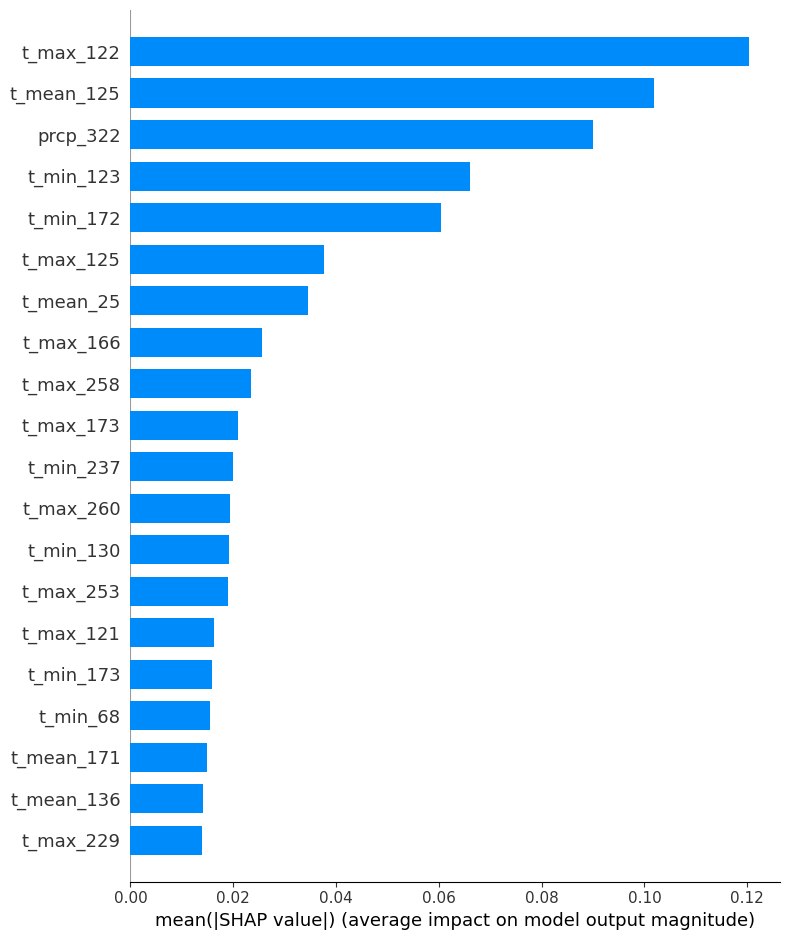

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

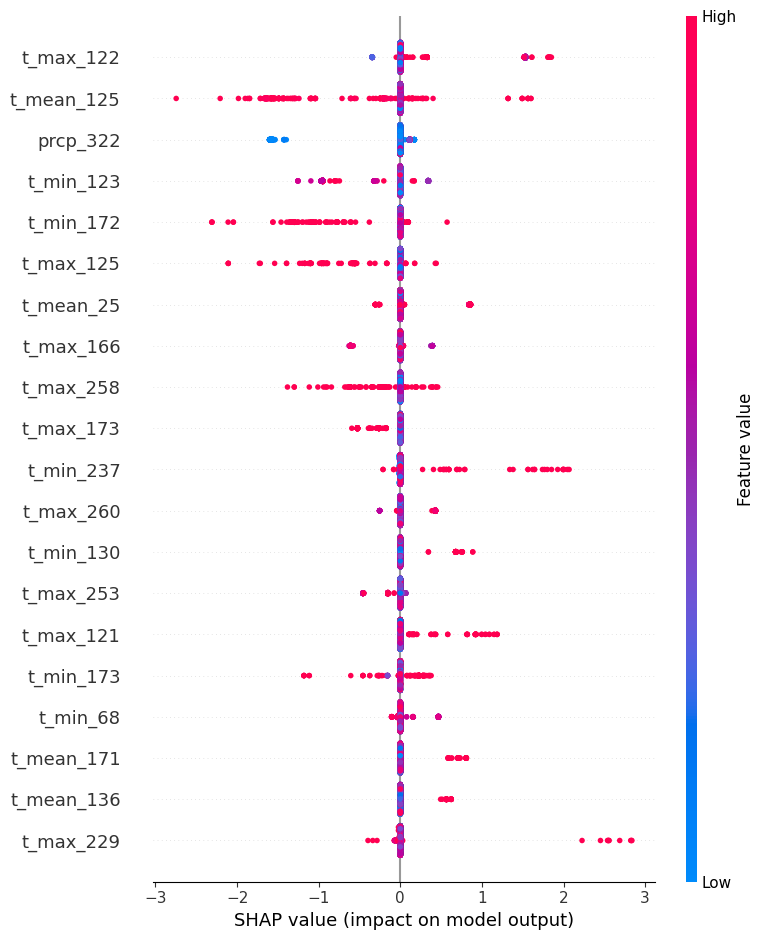

In [ ]:
shap.summary_plot(shap_values, X_test)